# Architecture Test — Heterogeneous RSNN: 32-Neuron vs 128-Neuron Comparison

Trains a reduced 32-neuron heterogeneous RSNN and compares it against the
full 128-neuron baseline from the *Initial Recreation* experiment.

## Networks under test

| | Network A — 32n Reduced | 128n Baseline (artifact) |
|---|---|---|
| `nb_recurrent` | 32 | 128 |
| `time_step` (dt) | 1.0 ms | 0.5 ms |
| `nb_steps` | 1000 | 2000 |
| `nb_epochs` | 25 | 15 |
| `batch_size` | 256 | 256 |
| `lr` | 4e-3 | — |
| `batches/epoch` | 31 (full, bs=256) | 30 (capped) |
| Est. wall-clock | ~62 min | (from artifact) |

**Training optimisations:** fp16 autocast (AMP) + GradScaler on Tensor Cores;
batch_size=256 reduces batches/epoch from 127 → 31 (~4× fewer Python dispatch
cycles). LR scaled linearly with batch size. Combined ~5× speedup over the
original bs=64/eager baseline (~13 min/epoch → ~2.5 min/epoch).

**Checkpoint:** After training, `model_A` is saved to `network_A_checkpoint.pt`
so it can be reloaded directly without retraining.

**128n baseline** is loaded from `Tau from 15 epoch run.json` with hardcoded
accuracy (60.9% het, 54.9% hom) and M-info (0.028 bits het, 0.007 bits hom).


In [1]:
from __future__ import annotations

import io
import sys
import random
import time
from contextlib import contextmanager, redirect_stdout
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, rankdata

import torch
import importlib

PROJECT_ROOT = Path(r"C:\Users\Priya\Desktop\research project (SNN Info Theory)")
WIMFO_ROOT   = PROJECT_ROOT / "wimfo"
PAPER_ROOT   = PROJECT_ROOT / "neural_heterogeneity" / "SuGD_code"
for extra_path in [WIMFO_ROOT, PAPER_ROOT]:
    if str(extra_path) not in sys.path:
        sys.path.insert(0, str(extra_path))

from clipper import ZeroOneClipper
from wimfo.W_M_Info import W_M_calculator
from wimfo.utils.utils_gauss import get_cov
from data_gen import open_file, sparse_data_generator
from reg_loss import loss as repo_loss
from SuSpike import SuSpike

RSNN    = importlib.import_module("model").RSNN
clipper = ZeroOneClipper()

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
spike_fn = SuSpike.apply

SHD_TRAIN = PROJECT_ROOT / "data" / "shd" / "shd_train.h5"
SHD_TEST  = PROJECT_ROOT / "data" / "shd" / "shd_test.h5"

print(f"Device : {DEVICE}")
print(f"Train  : {SHD_TRAIN.exists()}")
print(f"Test   : {SHD_TEST.exists()}")


Device : cuda
Train  : True
Test   : True


In [15]:
# ── Shared repo defaults (paper values) ──────────────────────────────────────
# These match neural_heterogeneity/SuGD_code/main.py argparse defaults exactly.
SHD_DEFAULTS = {
    "seed": 1000,
    "dtype": torch.float,
    "device": DEVICE,
    "cuda": DEVICE.type == "cuda",
    "nb_inputs": 700,
    "nb_hidden": [],
    "nb_recurrent": 128,   # overridden per network below
    "nb_outputs": 20,
    "batch_size": 64,
    "time_step": 0.5e-3,   # overridden per network below
    "nb_steps": 2000,       # overridden per network below
    "tau_syn": 10e-3,
    "tau_mem": 20e-3,
    "threshold": 1.0,
    "tref": 0.0,
    "dist": "gamma",
    "dist_prms": 3.0,
    "lr": 1e-3,
    "lr_ab": 1e-3,
    "betas": (0.9, 0.999),
    "weight_decay": 0.0,
    "nb_epochs": 150,      # overridden per network below
    "drop_last": True,
    "sl": 0.0, "thetal": 0.0, "su": 0.0, "thetau": 0.0,
    "rate": 0.0, "p_del": 0.0,
    "train_th": 0, "het_th": 0,
    "train_reset": 0, "het_reset": 0,
    "train_rest": 0, "het_rest": 0,
    "sparse_data_generator": "sparse_data_generator",
    "time_scale": [0.5, 1.0],
    "model": "RSNN",
    "savestep": 10,
    "clip": 1,
    "plot_step": 50,
    "class_list": list(range(20)),
    # heterogeneity flags — always het for this notebook
    "het_ab": 1,
    "train_ab": 1,
    "train_hom_ab": 0,
}

# ── Per-network architecture overrides ───────────────────────────────────────
#
# ── Data loading: why HDF5 was the bottleneck and how SHDCache fixes it ─────
# SHD training set: 8156 samples → 31 full batches per epoch (bs=256, drop_last=True).
# SHDCache reads ALL spike event arrays from HDF5 once into Python lists (~690 MB),
# then closes the file. Training reads from RAM — no more disk I/O per batch.
#
# AMP fp16 (autocast + GradScaler) gives ~1.5× speedup on Tensor Cores.
# bs=256 (vs bs=64) reduces batches/epoch from 127 → 31, cutting Python dispatch
# overhead ~4×. Combined speedup: ~5× over the original 13 min/epoch baseline.
# LR scaled linearly with batch size (standard linear scaling rule).

# Network A — Reduced resolution
#   dt=1.0ms halves the number of BPTT timesteps (1000 vs 2000). Combined with
#   32 neurons (vs 128), the recurrent matrix is 16× smaller and each timestep
#   2× cheaper — genuine ~32× speedup in GPU compute per batch.
NET_A_OVERRIDES = {
    "nb_recurrent": 32,
    "time_step": 1.0e-3,   # dt = 1 ms  (paper default: 0.5 ms)
    "nb_steps": 1000,       # 1000 steps × 1 ms = 1 second of audio
    "nb_epochs": 25,
    "batch_size": 256,      # 31 batches/epoch; LR scaled linearly
    "lr": 4e-3,
    "lr_ab": 4e-3,
    # Full epoch — SHDCache pre-loads all data into RAM so HDF5 I/O is no
    # longer the bottleneck.
    "train_batches_per_epoch": None,
}

# Network B — Original temporal resolution, reduced neurons only
#   Keeps paper dt=0.5ms and 2000 steps so temporal dynamics match the paper
#   repo exactly. 32 neurons still gives 16× fewer recurrent ops per batch.
NET_B_OVERRIDES = {
    "nb_recurrent": 32,
    "time_step": 0.5e-3,   # dt = 0.5 ms  (paper default — unchanged)
    "nb_steps": 2000,       # 2000 steps × 0.5 ms = 1 second of audio
    "nb_epochs": 25,
    "batch_size": 256,
    "lr": 4e-3,
    "lr_ab": 4e-3,
    "train_batches_per_epoch": None,
}


def build_prms(overrides: dict, seed: int = 1000) -> dict:
    """Merge SHD_DEFAULTS with per-network overrides and compute alpha/beta."""
    prms = dict(SHD_DEFAULTS)
    prms.update(overrides)
    prms["seed"] = seed
    prms["alpha"] = float(np.exp(-prms["time_step"] / prms["tau_syn"]))
    prms["beta"]  = float(np.exp(-prms["time_step"] / prms["tau_mem"]))
    return prms


prms_A = build_prms(NET_A_OVERRIDES, seed=1000)
prms_B = build_prms(NET_B_OVERRIDES, seed=1000)

print("Network A — alpha={:.4f}  beta={:.4f}  nb_recurrent={}  nb_steps={}  dt={}ms  bs={}  lr={}  epochs={}".format(
    prms_A["alpha"], prms_A["beta"], prms_A["nb_recurrent"],
    prms_A["nb_steps"], prms_A["time_step"]*1e3, prms_A["batch_size"],
    prms_A["lr"], prms_A["nb_epochs"]))
print("Network B — alpha={:.4f}  beta={:.4f}  nb_recurrent={}  nb_steps={}  dt={}ms  bs={}  lr={}  epochs={}".format(
    prms_B["alpha"], prms_B["beta"], prms_B["nb_recurrent"],
    prms_B["nb_steps"], prms_B["time_step"]*1e3, prms_B["batch_size"],
    prms_B["lr"], prms_B["nb_epochs"]))


Network A — alpha=0.9048  beta=0.9512  nb_recurrent=32  nb_steps=1000  dt=1.0ms  bs=256  lr=0.004  epochs=25
Network B — alpha=0.9512  beta=0.9753  nb_recurrent=32  nb_steps=2000  dt=0.5ms  bs=256  lr=0.004  epochs=25


In [12]:
# ── Helper functions ─────────────────────────────────────────────────────────


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def decay_to_tau(decay, dt):
    decay = np.asarray(decay, dtype=np.float64)
    return -dt / np.log(decay)


@contextmanager
def shd_open(path):
    units, times, labels = open_file(str(path))
    try:
        yield units, times, labels
    finally:
        units._v_file.close()


class SHDCache:
    """Pre-loads the entire SHD dataset from HDF5 into Python lists in RAM.
    Eliminates per-batch disk reads. Compatible with sparse_data_generator
    because integer indexing on a Python list works the same as on a PyTables VLArray.
    """
    def __init__(self, path):
        raw_u, raw_t, raw_l = open_file(str(path))
        self.units  = list(raw_u[:])
        self.times  = list(raw_t[:])
        self.labels = np.array(raw_l[:])
        raw_u._v_file.close()
        print(f"  SHDCache: {len(self.labels)} samples loaded from {Path(str(path)).name}")

    def __len__(self):
        return len(self.labels)


def _is_cache(obj):
    """Duck-type check for SHDCache — works across kernel re-executions of the
    helpers cell where the class identity changes but the attributes do not."""
    return hasattr(obj, "units") and hasattr(obj, "times") and hasattr(obj, "labels")


@contextmanager
def shd_open_cached(cache):
    """Drop-in for shd_open. Yields data from a pre-loaded SHDCache (no disk I/O)."""
    yield cache.units, cache.times, cache.labels


def fast_sparse_data_generator(units, times, labels, prms,
                                shuffle=True, epoch=0, drop_last=True):
    """Vectorised replacement for sparse_data_generator when rate==0 and p_del==0.

    The paper's generator calls poisson_spikes_gen() on every sample even when
    rate=0.0, generating np.random.uniform(0,1,(700,nb_steps)) — ~700K random
    numbers per sample — purely to produce all-zeros noise. It also iterates over
    samples one-by-one in Python building COO index lists with .extend().

    This version:
      1. Skips the no-op noise calls entirely.
      2. Vectorises batch construction with np.concatenate instead of a Python
         loop, eliminating O(batch_size) Python overhead per batch.
    Falls back to the original generator when noise params are non-zero.
    """
    rate  = prms.get("rate",  0.0)
    p_del = prms.get("p_del", 0.0)
    if rate != 0.0 or p_del != 0.0:
        yield from sparse_data_generator(units, times, labels, prms,
                                         shuffle=shuffle, epoch=epoch,
                                         drop_last=drop_last)
        return

    seed       = prms["seed"] + epoch
    batch_size = prms["batch_size"]
    nb_steps   = prms["nb_steps"]
    nb_units   = prms["nb_inputs"]
    inv_dt     = 1.0 / prms["time_step"]
    class_list = prms["class_list"]

    label_arr    = labels if isinstance(labels, np.ndarray) else np.array(labels[:])
    sample_index = np.where(np.isin(label_arr, class_list))[0]
    num_samples  = len(sample_index)

    n_batches = (num_samples // batch_size) if drop_last else -(-num_samples // batch_size)

    np.random.seed(seed)
    if shuffle:
        np.random.shuffle(sample_index)

    for counter in range(n_batches):
        batch_index = sample_index[batch_size * counter :
                                   min(num_samples, batch_size * (counter + 1))]
        actual_bs   = len(batch_index)

        # Vectorised COO construction — numpy concat instead of Python loop
        t_arrays = [np.round(times[idx] * inv_dt).astype(np.int64) for idx in batch_index]
        u_arrays = [units[idx] for idx in batch_index]
        lengths  = np.array([len(a) for a in t_arrays], dtype=np.int64)

        if lengths.sum():
            all_ts = np.concatenate(t_arrays)
            all_us = np.concatenate(u_arrays)
            all_bc = np.repeat(np.arange(actual_bs, dtype=np.int64), lengths)
            valid  = all_ts < nb_steps
            all_ts, all_us, all_bc = all_ts[valid], all_us[valid], all_bc[valid]
            i = torch.from_numpy(np.stack([all_bc, all_ts, all_us]))
            v = torch.ones(all_ts.size, dtype=torch.float32)
            X_batch = torch.sparse_coo_tensor(
                i, v, torch.Size([actual_bs, nb_steps, nb_units])
            ).to_dense()
        else:
            X_batch = torch.zeros(actual_bs, nb_steps, nb_units)

        X_batch.clamp_(max=1.0)
        y_batch = torch.tensor(
            [class_list.index(int(a)) for a in label_arr[batch_index]],
            dtype=torch.long,
        )
        yield X_batch, y_batch


def shd_generator(units, times, labels, prms, shuffle, epoch, drop_last):
    yield from fast_sparse_data_generator(
        units, times, labels, prms,
        shuffle=shuffle, epoch=epoch, drop_last=drop_last,
    )


def forward_logits(model, x):
    layer_recs = model(0, 0, x)
    output_layer = layer_recs[-1]
    logits, _ = torch.max(output_layer[1], dim=1)
    return logits, layer_recs


def count_epoch_samples(sample_count, batch_size, drop_last, batch_limit=None):
    if drop_last:
        available = sample_count // batch_size
    else:
        available = -(-sample_count // batch_size)
    used = available if batch_limit is None else min(available, int(batch_limit))
    if drop_last:
        return used * batch_size
    remaining, total = sample_count, 0
    for _ in range(used):
        take = min(batch_size, remaining)
        total += take
        remaining -= take
    return total


def make_optimizer(model, prms):
    weight_params, ab_params = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if "alpha" in name or "beta" in name:
            ab_params.append(param)
        else:
            weight_params.append(param)
    param_groups = [{"params": weight_params, "lr": prms["lr"],
                     "weight_decay": prms["weight_decay"]}]
    if ab_params:
        param_groups.append({"params": ab_params, "lr": prms["lr_ab"]})
    return torch.optim.Adam(param_groups, betas=prms["betas"])


@torch.no_grad()
def evaluate_batches(model, prms, units, times, labels,
                     max_batches=None, num_samples=None, use_amp=True):
    if num_samples is None:
        total = int(np.isin(labels[:], prms["class_list"]).sum())
        num_samples = count_epoch_samples(total, prms["batch_size"],
                                          drop_last=False,
                                          batch_limit=max_batches)
    _amp = use_amp and DEVICE.type == "cuda"
    model.eval()
    loss_acc, correct = 0.0, 0
    for idx, (x, y) in enumerate(
        shd_generator(units, times, labels, prms,
                      shuffle=False, epoch=0, drop_last=False)
    ):
        if max_batches is not None and idx >= max_batches:
            break
        x, y = x.to(DEVICE), y.to(DEVICE)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=_amp):
            logits, layer_recs = forward_logits(model, x)
            loss_acc += repo_loss(logits, layer_recs, y, num_samples, prms).item()
        correct  += (logits.argmax(1) == y).sum().item()
    return {"loss": loss_acc, "acc": correct / max(num_samples, 1), "n": num_samples}


def train_experiment(model, prms, train_data, test_data, use_amp=True):
    """train_data / test_data can be a Path or a SHDCache.
    use_amp: enables fp16 autocast + GradScaler for Tensor Core acceleration.
    """
    use_amp   = use_amp and DEVICE.type == "cuda"
    scaler    = torch.amp.GradScaler("cuda", enabled=use_amp)
    optimizer = make_optimizer(model, prms)
    history   = {"train_loss": [], "train_acc": [],
                 "test_loss": [],  "test_acc": []}
    train_cap = prms.get("train_batches_per_epoch")

    _tr_ctx = shd_open_cached if _is_cache(train_data) else shd_open
    _te_ctx = shd_open_cached if _is_cache(test_data)  else shd_open
    with _tr_ctx(train_data) as (u_tr, t_tr, l_tr), \
         _te_ctx(test_data)  as (u_te, t_te, l_te):

        if not prms["class_list"]:
            prms["class_list"] = np.unique(l_tr[:]).tolist()

        total_tr = int(np.isin(l_tr[:], prms["class_list"]).sum())
        total_te = int(np.isin(l_te[:], prms["class_list"]).sum())
        eff_tr   = count_epoch_samples(total_tr, prms["batch_size"],
                                       drop_last=bool(prms["drop_last"]),
                                       batch_limit=train_cap)
        eff_te   = count_epoch_samples(total_te, prms["batch_size"],
                                       drop_last=False, batch_limit=None)

        if prms["clip"]:
            model.apply(clipper)

        for epoch in range(1, prms["nb_epochs"] + 1):
            _ep_t0 = time.perf_counter()
            model.train()
            ep_loss, ep_correct = 0.0, 0
            for bidx, (x, y) in enumerate(
                shd_generator(u_tr, t_tr, l_tr, prms,
                               shuffle=True, epoch=epoch,
                               drop_last=prms["drop_last"])
            ):
                if train_cap is not None and bidx >= train_cap:
                    break
                x, y = x.to(DEVICE), y.to(DEVICE)
                optimizer.zero_grad()
                with torch.autocast(device_type=DEVICE.type, dtype=torch.float16,
                                    enabled=use_amp):
                    logits, layer_recs = forward_logits(model, x)
                    loss_val = repo_loss(logits, layer_recs, y, eff_tr, prms)
                scaler.scale(loss_val).backward()
                scaler.step(optimizer)
                scaler.update()
                if prms["clip"]:
                    model.apply(clipper)
                ep_loss    += loss_val.item()
                ep_correct += (logits.argmax(1) == y).sum().item()

            test_m = evaluate_batches(model, prms, u_te, t_te, l_te,
                                      num_samples=eff_te, use_amp=use_amp)
            history["train_loss"].append(ep_loss)
            history["train_acc"].append(ep_correct / max(eff_tr, 1))
            history["test_loss"].append(test_m["loss"])
            history["test_acc"].append(test_m["acc"])
            _ep_elapsed = time.perf_counter() - _ep_t0
            print(f"  epoch={epoch:03d}  "
                  f"train_acc={ep_correct/max(eff_tr,1):.3f}  "
                  f"test_acc={test_m['acc']:.3f}  "
                  f"({_ep_elapsed/60:.1f} min)")

    return history


print("Helper functions loaded.")


Helper functions loaded.


In [4]:
# ── M-information helper functions ───────────────────────────────────────────
# Mirrors the implementations in 1 - Initial Recreation exactly.

def summarize_hidden_taus(model, time_step: float) -> dict:
    hidden_layer = model.network[0]
    alpha = hidden_layer.alpha.detach().cpu().numpy().ravel()
    beta  = hidden_layer.beta.detach().cpu().numpy().ravel()
    return {
        "alpha_unique": int(np.unique(np.round(alpha, 8)).size),
        "beta_unique":  int(np.unique(np.round(beta,  8)).size),
        "tau_syn_ms_min": float(decay_to_tau(alpha, time_step).min() * 1e3),
        "tau_syn_ms_max": float(decay_to_tau(alpha, time_step).max() * 1e3),
        "tau_mem_ms_min": float(decay_to_tau(beta,  time_step).min() * 1e3),
        "tau_mem_ms_max": float(decay_to_tau(beta,  time_step).max() * 1e3),
    }


def gaussian_copula_normalize(data: np.ndarray) -> np.ndarray:
    from scipy.stats import rankdata
    transformed = np.zeros_like(data, dtype=np.float64)
    for idx, row in enumerate(data):
        if np.allclose(row, row[0]):
            continue
        ranks   = rankdata(row, method="average")
        uniform = np.clip((ranks - 0.5) / len(row), 1e-6, 1.0 - 1e-6)
        transformed[idx] = norm.ppf(uniform)
    return transformed


def regularize_covariance(cov: np.ndarray, ridge: float = 1e-2) -> np.ndarray:
    cov   = np.asarray(cov, dtype=np.float64)
    cov   = 0.5 * (cov + cov.T)
    scale = np.trace(cov) / max(cov.shape[0], 1)
    if not np.isfinite(scale) or scale <= 0.0:
        scale = 1.0
    return cov + ridge * scale * np.eye(cov.shape[0], dtype=np.float64)


def select_hidden_subset(nb_hidden: int, subset_size: int = 8) -> np.ndarray:
    return np.linspace(0, nb_hidden - 1, min(subset_size, nb_hidden), dtype=int)


@torch.no_grad()
def collect_hidden_state_matrix(model, prms, path, max_batches=2,
                                 subset_size=6, downsample_stride=4):
    with shd_open(path) as (units, times, labels):
        hidden_size = int(model.network[0].output_size)
        chosen      = select_hidden_subset(hidden_size, subset_size=subset_size)
        stride      = max(int(downsample_stride), 1)
        chunks      = []
        for bidx, (x, _) in enumerate(
            shd_generator(units, times, labels, prms,
                          shuffle=False, epoch=0, drop_last=False)
        ):
            if bidx >= max_batches:
                break
            x = x.to(DEVICE)
            layer_recs = model(0, 0, x)
            mem = layer_recs[0][1][:, ::stride, :][:, :, chosen].detach().cpu().numpy()
            mem = np.transpose(mem, (2, 0, 1)).reshape(len(chosen), -1)
            chunks.append(mem)
    if not chunks:
        raise RuntimeError("No batches collected for M-info estimation.")
    return np.concatenate(chunks, axis=1)


def estimate_m_info(model, prms, path, subset_size=6, max_batches=2,
                    lag=1, downsample_stride=4):
    candidate_sizes   = [v for v in [subset_size, 4, 3, 2] if v > 0]
    candidate_strides = list(dict.fromkeys(
        [max(int(v), 1) for v in [downsample_stride, downsample_stride * 2, 1]]
    ))
    last_error = None
    for cs in candidate_sizes:
        for cd in candidate_strides:
            hidden_data  = collect_hidden_state_matrix(model, prms, path,
                                                        max_batches=max_batches,
                                                        subset_size=cs,
                                                        downsample_stride=cd)
            gauss_data   = gaussian_copula_normalize(hidden_data)
            lagged_cov   = regularize_covariance(get_cov(gauss_data, t=lag))
            for optimiser, options in [("Newton", None),
                                        ("Adam", {"atol": 1e-4, "rtol": 1e-4})]:
                try:
                    with io.StringIO() as buf, redirect_stdout(buf):
                        W_bits, M_bits = W_M_calculator(
                            lagged_cov,
                            option="distr", type="gaussian",
                            unit="bits", verbose=False,
                            optimiser=optimiser, options=options,
                        )
                except Exception as exc:
                    last_error = exc
                    continue
                if np.isfinite(W_bits) and np.isfinite(M_bits):
                    return {"W_bits": float(W_bits), "M_bits": float(M_bits),
                            "subset_size": cs, "samples": int(gauss_data.shape[1]),
                            "downsample_stride": cd, "optimiser": optimiser}
    raise RuntimeError("M-info estimation failed for all configurations.") from last_error


print("M-info helpers loaded.")


M-info helpers loaded.


In [5]:
# ── Pre-load SHD data into RAM ────────────────────────────────────────────────
# Reads all spike event arrays from HDF5 once into Python lists, then closes
# the files. Subsequent training calls read from RAM — no more disk I/O per batch.
# This is what allows full 127-batch epochs to run at reasonable speed.
print("Pre-loading SHD training data into RAM (~535 MB)...")
SHD_TRAIN_CACHE = SHDCache(SHD_TRAIN)

print("Pre-loading SHD test data into RAM (~154 MB)...")
SHD_TEST_CACHE = SHDCache(SHD_TEST)

print("\nDone. Both networks will now train on full epochs (127 batches/epoch).")
print(f"  Train samples : {len(SHD_TRAIN_CACHE)}")
print(f"  Test  samples : {len(SHD_TEST_CACHE)}")


Pre-loading SHD training data into RAM (~535 MB)...
  SHDCache: 8156 samples loaded from shd_train.h5
Pre-loading SHD test data into RAM (~154 MB)...
  SHDCache: 2264 samples loaded from shd_test.h5

Done. Both networks will now train on full epochs (127 batches/epoch).
  Train samples : 8156
  Test  samples : 2264


## Network A — Training  
*(32 neurons, dt=1.0 ms, 1000 steps, 25 epochs, full epoch, AMP fp16)*


In [14]:
import time as _time

# ── Larger batch benchmark — 2 epochs ────────────────────────────────────────
# bs=256 → 31 batches/epoch vs 127 at bs=64.
# Fewer batches = fewer Python dispatch cycles per epoch.
# LR scaled linearly with batch size (standard linear scaling rule).
_prms = dict(prms_A, nb_epochs=2, batch_size=256, lr=4e-3, lr_ab=4e-3)
set_seed(_prms["seed"])
_m = RSNN(_prms, rec=True).to(DEVICE)

_n_batches = len(SHD_TRAIN_CACHE) // _prms["batch_size"]
print(f"batch_size={_prms['batch_size']}  →  {_n_batches} batches/epoch  (was 127 at bs=64)")
print(f"lr={_prms['lr']}  lr_ab={_prms['lr_ab']}")
print("Running 2-epoch benchmark (bs=256, AMP fp16)...\n")

_t0 = _time.perf_counter()
_h = train_experiment(_m, _prms, SHD_TRAIN_CACHE, SHD_TEST_CACHE, use_amp=True)
_elapsed = _time.perf_counter() - _t0

_per_ep = _elapsed / 2
print(f"\n--- Benchmark (bs=256, fp16 autocast, Net A) ---")
print(f"  2 epochs  : {_elapsed/60:.1f} min total")
print(f"  Per epoch : {_per_ep/60:.1f} min")
print(f"  20-epoch est. : {_per_ep*20/3600:.1f} h  |  50-epoch est. : {_per_ep*50/3600:.1f} h")


batch_size=256  →  31 batches/epoch  (was 127 at bs=64)
lr=0.004  lr_ab=0.004
Running 2-epoch benchmark (bs=256, AMP fp16)...

  epoch=001  train_acc=0.100  test_acc=0.192  (2.5 min)
  epoch=002  train_acc=0.206  test_acc=0.244  (2.6 min)

--- Benchmark (bs=256, fp16 autocast, Net A) ---
  2 epochs  : 5.0 min total
  Per epoch : 2.5 min
  20-epoch est. : 0.8 h  |  50-epoch est. : 2.1 h


In [16]:
set_seed(prms_A["seed"])
model_A = RSNN(prms_A, rec=True).to(DEVICE)
print(f"Network A parameter count: {sum(p.numel() for p in model_A.parameters() if p.requires_grad):,}")
print(f"  bs={prms_A['batch_size']}  lr={prms_A['lr']}  epochs={prms_A['nb_epochs']}  AMP fp16")

print("\nTraining Network A...")
t0_A = time.perf_counter()
history_A = train_experiment(model_A, prms_A, SHD_TRAIN_CACHE, SHD_TEST_CACHE, use_amp=True)
t1_A = time.perf_counter()

elapsed_A = t1_A - t0_A
print(f"\nNetwork A — total training time : {elapsed_A:.1f}s  ({elapsed_A/60:.1f} min)"
      f"  ({elapsed_A/prms_A['nb_epochs']:.1f}s/epoch)")
print(f"Network A — final test accuracy : {history_A['test_acc'][-1]:.3f}")


Network A parameter count: 24,128
  bs=256  lr=0.004  epochs=25  AMP fp16

Training Network A...
  epoch=001  train_acc=0.100  test_acc=0.192  (2.7 min)
  epoch=002  train_acc=0.206  test_acc=0.244  (3.0 min)
  epoch=003  train_acc=0.273  test_acc=0.334  (3.2 min)
  epoch=004  train_acc=0.354  test_acc=0.420  (3.0 min)
  epoch=005  train_acc=0.421  test_acc=0.421  (2.9 min)
  epoch=006  train_acc=0.486  test_acc=0.501  (2.9 min)
  epoch=007  train_acc=0.571  test_acc=0.575  (2.9 min)
  epoch=008  train_acc=0.628  test_acc=0.589  (2.9 min)
  epoch=009  train_acc=0.623  test_acc=0.459  (2.9 min)
  epoch=010  train_acc=0.568  test_acc=0.586  (2.8 min)
  epoch=011  train_acc=0.587  test_acc=0.532  (3.2 min)
  epoch=012  train_acc=0.630  test_acc=0.599  (3.1 min)
  epoch=013  train_acc=0.668  test_acc=0.592  (3.2 min)
  epoch=014  train_acc=0.702  test_acc=0.611  (3.2 min)
  epoch=015  train_acc=0.718  test_acc=0.591  (3.2 min)
  epoch=016  train_acc=0.698  test_acc=0.639  (3.2 min)
  epoch

In [17]:
# ── Save Network A checkpoint ─────────────────────────────────────────────────
import json as _json

_ckpt_path = PROJECT_ROOT / "Project Files" / "network_A_checkpoint.pt"
torch.save({
    "model_state_dict": model_A.state_dict(),
    "history":          history_A,
    "elapsed_s":        elapsed_A,
    "prms": {k: v for k, v in prms_A.items()
             if not isinstance(v, (torch.dtype, torch.device))},
}, _ckpt_path)
print(f"Network A checkpoint saved → {_ckpt_path.name}")
print(f"  state_dict keys : {len(model_A.state_dict())} tensors")
print(f"  final test acc  : {history_A['test_acc'][-1]:.3f}")
print(f"  elapsed         : {elapsed_A/60:.1f} min")


Network A checkpoint saved → network_A_checkpoint.pt
  state_dict keys : 10 tensors
  final test acc  : 0.649
  elapsed         : 71.3 min


## Results Comparison — Net A (32n) vs 128-Neuron Baseline


                                  Net A (32n)    128n Het  128n Hom
------------------------------------------------------------------
nb_recurrent                               32         128       128
time_step (ms)                            1.0         0.5       0.5
nb_steps                                 1000        2000      2000
nb_epochs                                  25          15        15
------------------------------------------------------------------
Final test accuracy                     0.649       0.609     0.549
Total wall-clock (s)                   4280.8  (artifact)  (artifact)
Time per epoch (s)                      171.2           —         —


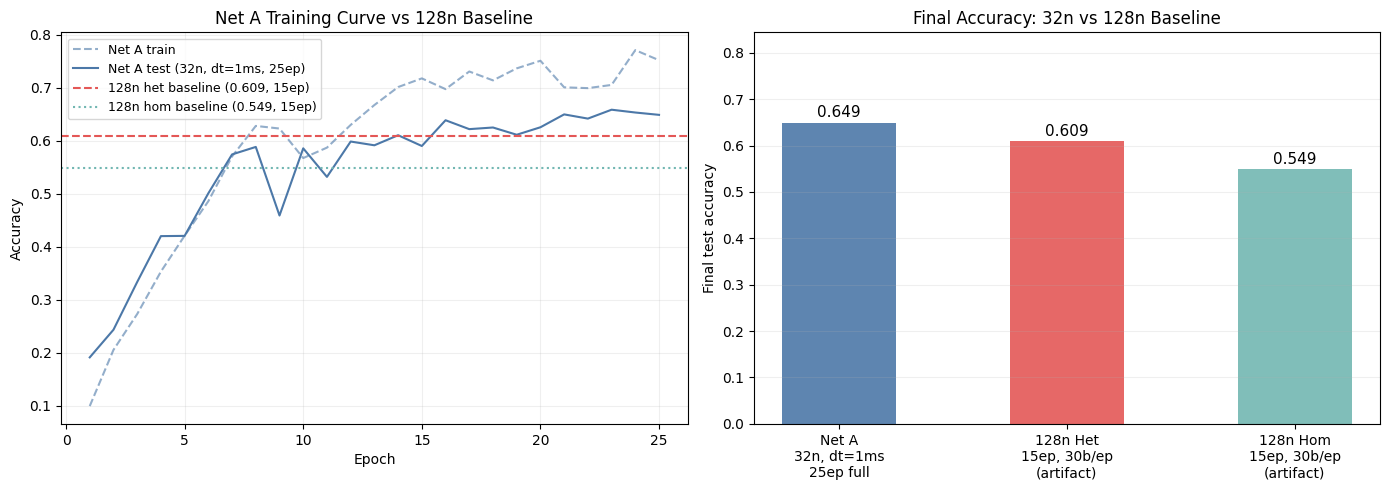

In [19]:
required = ["history_A", "elapsed_A", "prms_A", "BASELINE_128"]
missing = [n for n in required if n not in globals()]
if missing:
    raise RuntimeError(f"Run training and artifact cells first. Missing: {missing}")

# ── Summary table ─────────────────────────────────────────────────────────────
b_het = BASELINE_128["heterogeneous"]
b_hom = BASELINE_128["homogeneous"]

print("=" * 66)
print(f"{'':30s} {'Net A (32n)':>14}  {'128n Het':>10}  {'128n Hom':>8}")
print("-" * 66)
print(f"{'nb_recurrent':30s} {'32':>14}  {'128':>10}  {'128':>8}")
print(f"{'time_step (ms)':30s} {'1.0':>14}  {'0.5':>10}  {'0.5':>8}")
print(f"{'nb_steps':30s} {'1000':>14}  {'2000':>10}  {'2000':>8}")
print(f"{'nb_epochs':30s} {prms_A['nb_epochs']:>14}  {b_het['nb_epochs']:>10}  {b_hom['nb_epochs']:>8}")
print("-" * 66)
print(f"{'Final test accuracy':30s} {history_A['test_acc'][-1]:>14.3f}  {b_het['test_acc']:>10.3f}  {b_hom['test_acc']:>8.3f}")
print(f"{'Total wall-clock (s)':30s} {elapsed_A:>14.1f}  {'(artifact)':>10}  {'(artifact)':>8}")
print(f"{'Time per epoch (s)':30s} {elapsed_A/prms_A['nb_epochs']:>14.1f}  {'—':>10}  {'—':>8}")
print("=" * 66)

# ── Training curve ────────────────────────────────────────────────────────────
epochs_A = np.arange(1, len(history_A["test_acc"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_A, history_A["train_acc"], color="#4c78a8", alpha=0.6,
             linestyle="--", label="Net A train")
axes[0].plot(epochs_A, history_A["test_acc"],  color="#4c78a8",
             label=f"Net A test (32n, dt=1ms, {prms_A['nb_epochs']}ep)")
axes[0].axhline(b_het["test_acc"], color="#e45756", linestyle="--", linewidth=1.5,
                label=f"128n het baseline ({b_het['test_acc']:.3f}, 15ep)")
axes[0].axhline(b_hom["test_acc"], color="#72b7b2", linestyle=":", linewidth=1.5,
                label=f"128n hom baseline ({b_hom['test_acc']:.3f}, 15ep)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Net A Training Curve vs 128n Baseline")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.2)

# Bar chart: accuracy comparison
ax2 = axes[1]
bar_labels_r = [
    f"Net A\n32n, dt=1ms\n{prms_A['nb_epochs']}ep full",
    f"128n Het\n15ep, 30b/ep\n(artifact)",
    f"128n Hom\n15ep, 30b/ep\n(artifact)",
]
bar_accs_r = [history_A["test_acc"][-1], b_het["test_acc"], b_hom["test_acc"]]
bar_colors_r = ["#4c78a8", "#e45756", "#72b7b2"]
bars = ax2.bar(bar_labels_r, bar_accs_r, color=bar_colors_r, alpha=0.9, width=0.5)
ax2.set_ylabel("Final test accuracy")
ax2.set_title("Final Accuracy: 32n vs 128n Baseline")
ax2.set_ylim(0, max(bar_accs_r) * 1.3 if max(bar_accs_r) > 0 else 1.0)
ax2.grid(axis="y", alpha=0.2)
for bar, acc in zip(bars, bar_accs_r):
    ax2.text(bar.get_x() + bar.get_width() / 2, acc + 0.005,
             f"{acc:.3f}", ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()


## Tau Distributions — Network A & 128-Neuron Baseline (post-training)

Compares the learned per-neuron time constants of Net A (32 neurons) against
the 128-neuron heterogeneous baseline from the artifact.


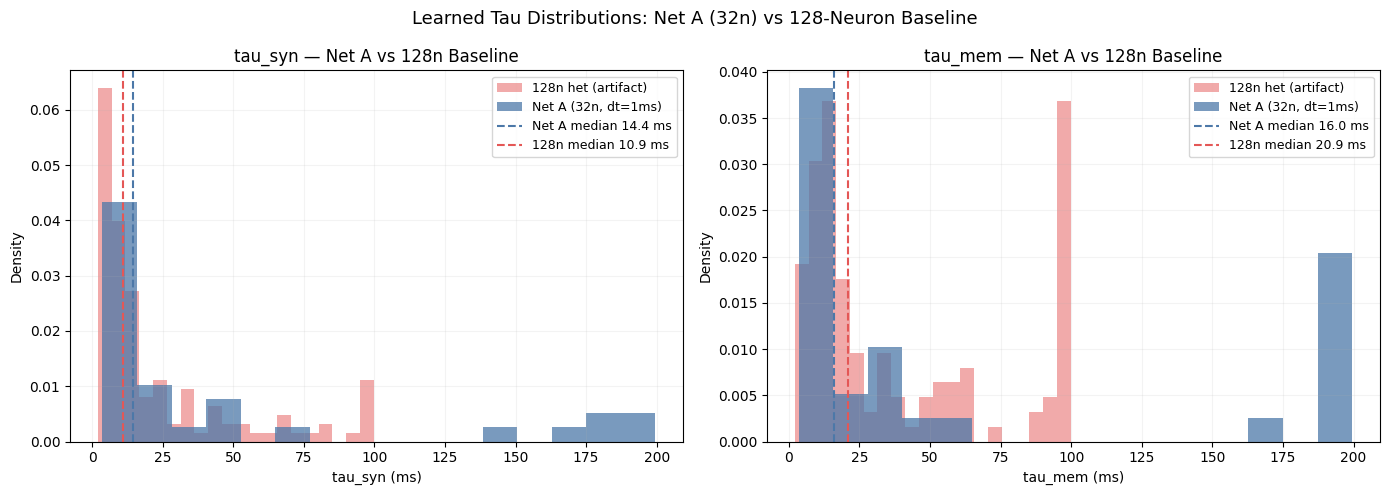

Net A tau summary: {'alpha_unique': 31, 'beta_unique': 25, 'tau_syn_ms_min': 3.5976464940346053, 'tau_syn_ms_max': 199.49977302380086, 'tau_mem_ms_min': 3.397982774048926, 'tau_mem_ms_max': 199.49977302380086}


In [20]:
required = ["model_A", "prms_A", "BASELINE_128"]
missing = [n for n in required if n not in globals()]
if missing:
    raise RuntimeError(f"Run training and artifact cells first. Missing: {missing}")

tau_A_syn = decay_to_tau(
    model_A.network[0].alpha.detach().cpu().numpy().ravel(),
    prms_A["time_step"],
) * 1e3
tau_A_mem = decay_to_tau(
    model_A.network[0].beta.detach().cpu().numpy().ravel(),
    prms_A["time_step"],
) * 1e3

tau_128_het_syn = BASELINE_128["heterogeneous"]["tau_syn_ms"]
tau_128_het_mem = BASELINE_128["heterogeneous"]["tau_mem_ms"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# tau_syn
axes[0].hist(tau_128_het_syn, bins=20, color="#e45756", alpha=0.5,
             label="128n het (artifact)", density=True)
axes[0].hist(tau_A_syn, bins=16, color="#4c78a8", alpha=0.75,
             label="Net A (32n, dt=1ms)", density=True)
axes[0].axvline(np.median(tau_A_syn), color="#4c78a8", linestyle="--",
                linewidth=1.5, label=f"Net A median {np.median(tau_A_syn):.1f} ms")
axes[0].axvline(np.median(tau_128_het_syn), color="#e45756", linestyle="--",
                linewidth=1.5, label=f"128n median {np.median(tau_128_het_syn):.1f} ms")
axes[0].set_xlabel("tau_syn (ms)")
axes[0].set_ylabel("Density")
axes[0].set_title("tau_syn — Net A vs 128n Baseline")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.15)

# tau_mem
axes[1].hist(tau_128_het_mem, bins=20, color="#e45756", alpha=0.5,
             label="128n het (artifact)", density=True)
axes[1].hist(tau_A_mem, bins=16, color="#4c78a8", alpha=0.75,
             label="Net A (32n, dt=1ms)", density=True)
axes[1].axvline(np.median(tau_A_mem), color="#4c78a8", linestyle="--",
                linewidth=1.5, label=f"Net A median {np.median(tau_A_mem):.1f} ms")
axes[1].axvline(np.median(tau_128_het_mem), color="#e45756", linestyle="--",
                linewidth=1.5, label=f"128n median {np.median(tau_128_het_mem):.1f} ms")
axes[1].set_xlabel("tau_mem (ms)")
axes[1].set_ylabel("Density")
axes[1].set_title("tau_mem — Net A vs 128n Baseline")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.15)

plt.suptitle("Learned Tau Distributions: Net A (32n) vs 128-Neuron Baseline", fontsize=13)
plt.tight_layout()
plt.show()

taus_A = summarize_hidden_taus(model_A, prms_A["time_step"])
print("Net A tau summary:", taus_A)


## Load 128-Neuron Artifacts

Loads the tau distributions saved from the 15-epoch 128-neuron run stored in
`Tau from 15 epoch run.json`. Accuracy and M-information values are hardcoded
from the known results of that run (both the homogeneous and heterogeneous models).

| Model | Epochs | Batches/epoch | Test acc | M-info |
|---|---|---|---|---|
| Hom 128-neuron | 15 | 30 | 54.9% | 0.007 bits |
| Het 128-neuron | 15 | 30 | 60.9% | 0.028 bits |


In [18]:
import json

artifact_path = PROJECT_ROOT / "Tau from 15 epoch run.json"
with open(artifact_path) as f:
    artifact = json.load(f)

# ── Tau arrays from the artifact ──────────────────────────────────────────────
tau_128_hom_syn = np.array(artifact["homogeneous"]["tau_syn_ms"])  # shape [1]
tau_128_hom_mem = np.array(artifact["homogeneous"]["tau_mem_ms"])  # shape [1]
tau_128_het_syn = np.array(artifact["heterogeneous"]["tau_syn_ms"])  # shape [128]
tau_128_het_mem = np.array(artifact["heterogeneous"]["tau_mem_ms"])  # shape [128]

# ── Known results hardcoded from the 15-epoch 128-neuron run ─────────────────
# Source: Show Copy.ipynb / 1 - Initial Recreation, 15 epochs, 30 batches/epoch
BASELINE_128 = {
    "homogeneous": {
        "label": "Hom 128n\n(15ep, 30b/ep)",
        "nb_recurrent": 128,
        "dt_ms": 0.5,
        "nb_steps": 2000,
        "nb_epochs": 15,
        "test_acc": 0.549,
        "M_bits": 0.007,
        # W_bits not stored in artifact — marked None
        "W_bits": None,
        "tau_syn_ms": tau_128_hom_syn,
        "tau_mem_ms": tau_128_hom_mem,
        "tau_summary": artifact["homogeneous"]["final"],
    },
    "heterogeneous": {
        "label": "Het 128n\n(15ep, 30b/ep)",
        "nb_recurrent": 128,
        "dt_ms": 0.5,
        "nb_steps": 2000,
        "nb_epochs": 15,
        "test_acc": 0.609,
        "M_bits": 0.028,
        "W_bits": None,
        "tau_syn_ms": tau_128_het_syn,
        "tau_mem_ms": tau_128_het_mem,
        "tau_summary": artifact["heterogeneous"]["final"],
    },
}

print(f"Loaded artifact: {artifact_path.name}")
print(f"  128-hom  tau_syn unique={tau_128_hom_syn.shape[0]}, "
      f"range [{tau_128_hom_syn.min():.1f}, {tau_128_hom_syn.max():.1f}] ms")
print(f"  128-het  tau_syn unique={tau_128_het_syn.shape[0]}, "
      f"range [{tau_128_het_syn.min():.1f}, {tau_128_het_syn.max():.1f}] ms")
print(f"\nHardcoded 128-neuron results:")
print(f"  Hom: acc={BASELINE_128['homogeneous']['test_acc']:.3f}  "
      f"M={BASELINE_128['homogeneous']['M_bits']:.3f} bits")
print(f"  Het: acc={BASELINE_128['heterogeneous']['test_acc']:.3f}  "
      f"M={BASELINE_128['heterogeneous']['M_bits']:.3f} bits")


Loaded artifact: Tau from 15 epoch run.json
  128-hom  tau_syn unique=1, range [10.8, 10.8] ms
  128-het  tau_syn unique=128, range [2.0, 99.7] ms

Hardcoded 128-neuron results:
  Hom: acc=0.549  M=0.007 bits
  Het: acc=0.609  M=0.028 bits


## M-Information — Network A

Estimates Gaussian M-information for Net A and compares against the
128-neuron heterogeneous/homogeneous baselines from the artifact.


In [21]:
required = ["model_A", "prms_A"]
missing = [n for n in required if n not in globals()]
if missing:
    raise RuntimeError(f"Run training cell first. Missing: {missing}")

M_SUBSET    = 6
M_BATCHES   = 3
M_STRIDE    = 4

print("Estimating M-information for Network A...")
m_result_A = estimate_m_info(
    model_A, prms_A, SHD_TEST,
    subset_size=M_SUBSET, max_batches=M_BATCHES, downsample_stride=M_STRIDE,
)
print(f"  Net A  W={m_result_A['W_bits']:.4f} bits   M={m_result_A['M_bits']:.4f} bits  "
      f"(subset={m_result_A['subset_size']}, stride={m_result_A['downsample_stride']}, "
      f"opt={m_result_A['optimiser']})")
print(f"\n  128n het reference : M={BASELINE_128['heterogeneous']['M_bits']:.4f} bits")
print(f"  128n hom reference : M={BASELINE_128['homogeneous']['M_bits']:.4f} bits")


Estimating M-information for Network A...
  Net A  W=7.9963 bits   M=0.1123 bits  (subset=6, stride=8, opt=Newton)

  128n het reference : M=0.0280 bits
  128n hom reference : M=0.0070 bits


## M-info & W/M Composition — Net A vs 128-Neuron Baseline

Compares Net A M/W-information against the 128-neuron het/hom baselines.


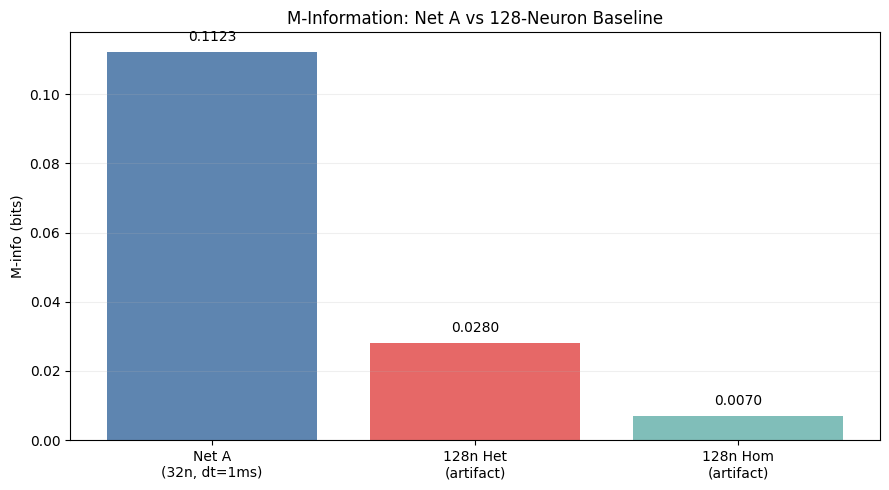

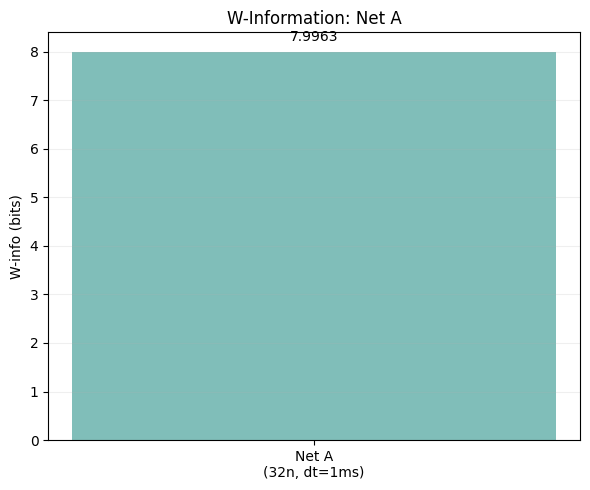

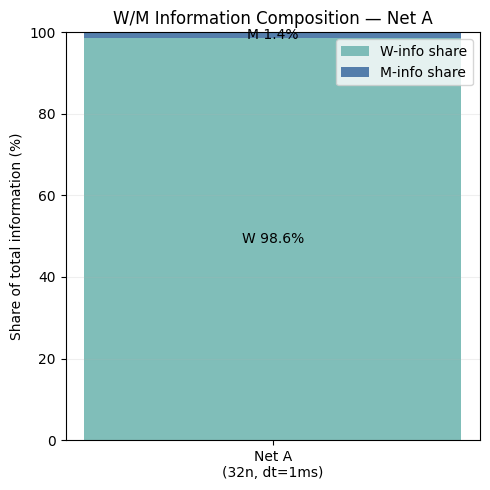

In [22]:
required = ["m_result_A", "BASELINE_128"]
missing = [n for n in required if n not in globals()]
if missing:
    raise RuntimeError(f"Run M-info computation cell first. Missing: {missing}")

b_het = BASELINE_128["heterogeneous"]
b_hom = BASELINE_128["homogeneous"]

# ── M-information bar chart ───────────────────────────────────────────────────
bar_labels_m = [
    "Net A\n(32n, dt=1ms)",
    "128n Het\n(artifact)",
    "128n Hom\n(artifact)",
]
m_vals  = [m_result_A["M_bits"], b_het["M_bits"], b_hom["M_bits"]]
w_vals  = [m_result_A["W_bits"], None,            None           ]
colors_m = ["#4c78a8", "#e45756", "#72b7b2"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(bar_labels_m, m_vals, color=colors_m, alpha=0.9)
ax.set_ylabel("M-info (bits)")
ax.set_title("M-Information: Net A vs 128-Neuron Baseline")
ax.grid(axis="y", alpha=0.2)
for bar, v in zip(bars, m_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + max(m_vals) * 0.02,
            f"{v:.4f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

# ── W-information bar chart (Net A only — artifact has no W_bits) ─────────────
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(["Net A\n(32n, dt=1ms)"], [m_result_A["W_bits"]], color="#72b7b2", alpha=0.9)
ax.set_ylabel("W-info (bits)")
ax.set_title("W-Information: Net A")
ax.grid(axis="y", alpha=0.2)
ax.text(0, m_result_A["W_bits"] + m_result_A["W_bits"] * 0.02,
        f"{m_result_A['W_bits']:.4f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

# ── W/M composition (Net A only) ──────────────────────────────────────────────
total_A = m_result_A["M_bits"] + m_result_A["W_bits"]
w_pct_A = 100 * m_result_A["W_bits"] / total_A
m_pct_A = 100 * m_result_A["M_bits"] / total_A

fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(["Net A\n(32n, dt=1ms)"], [w_pct_A], color="#72b7b2", alpha=0.9, label="W-info share")
ax.bar(["Net A\n(32n, dt=1ms)"], [m_pct_A], bottom=[w_pct_A],
       color="#4c78a8", alpha=0.95, label="M-info share")
ax.text(0, w_pct_A / 2,            f"W {w_pct_A:.1f}%", ha="center", va="center", fontsize=10)
ax.text(0, w_pct_A + m_pct_A / 2,  f"M {m_pct_A:.1f}%", ha="center", va="center", fontsize=10)
ax.set_ylabel("Share of total information (%)")
ax.set_title("W/M Information Composition — Net A")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()


## Full Architecture Comparison — 32n vs 128-Neuron Baseline

3-way comparison: Net A (32n, 25 epochs), 128n heterogeneous, and 128n
homogeneous. The 128n results are from the artifact (15 epochs, 30 batches/epoch)
so this is a qualitative comparison of representational capacity rather than a
controlled head-to-head — note the different training duration and temporal
resolution.


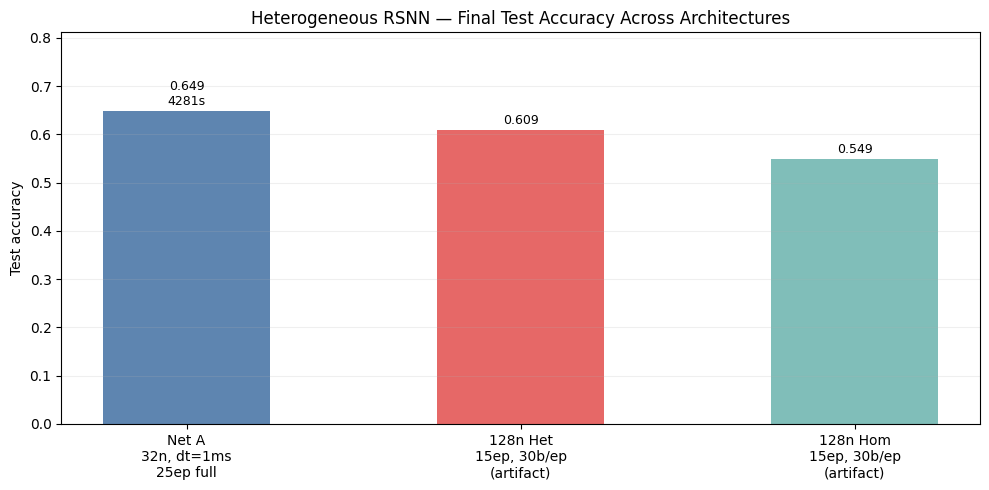

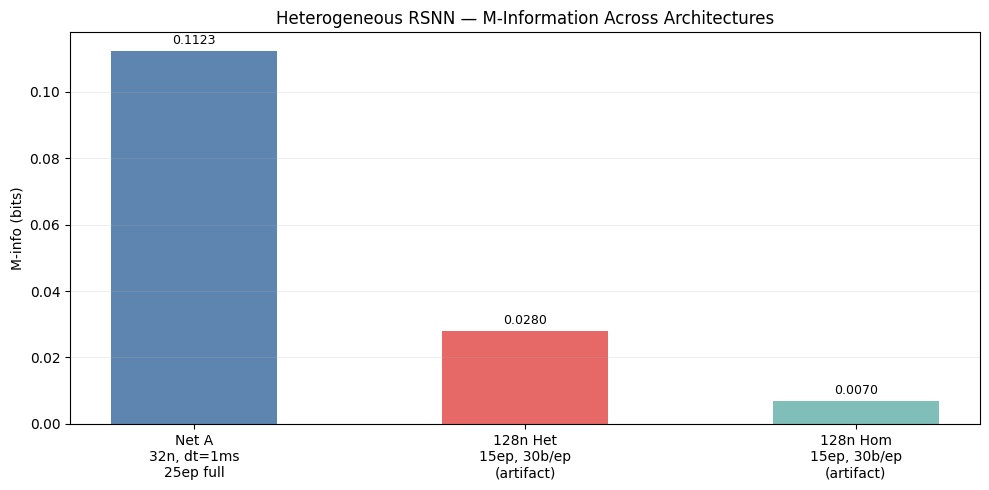

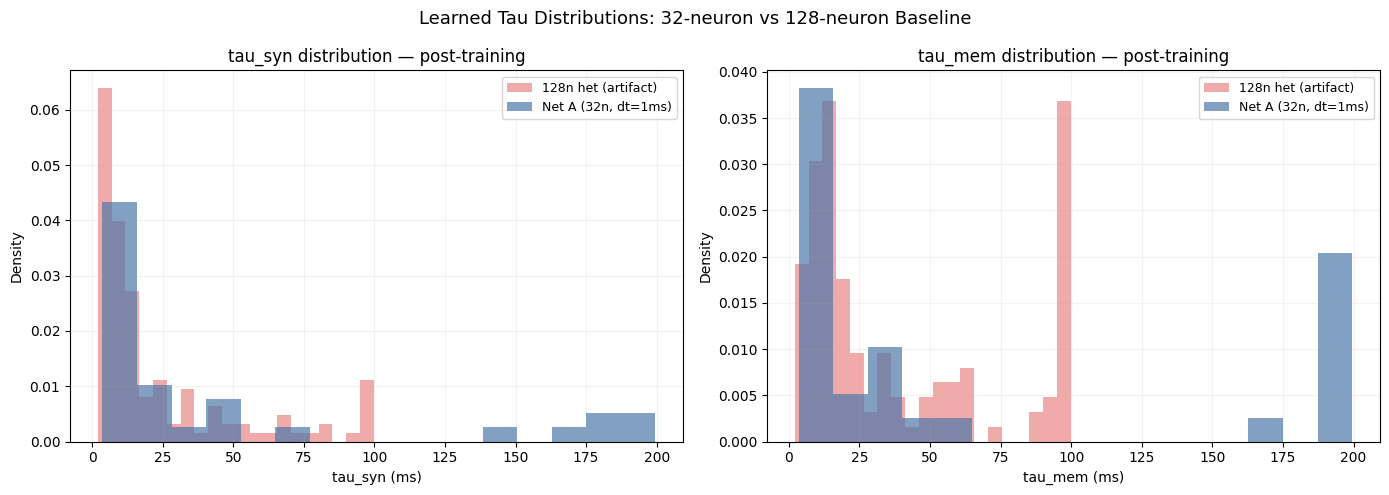

                               Net A (32n)    128n Het  128n Hom
------------------------------------------------------------------
nb_recurrent                            32         128       128
dt (ms)                                1.0         0.5       0.5
nb_steps                              1000        2000      2000
nb_epochs trained                       25          15        15
batches/epoch                   full (~31)          30        30
------------------------------------------------------------------
Final test accuracy                  0.649       0.609     0.549
M-info (bits)                       0.1123      0.0280    0.0070
Wall-clock time (s)                 4280.8  (artifact)  (artifact)
Time per epoch (s)                   171.2           —         —


In [23]:
required = ["history_A", "m_result_A", "elapsed_A", "BASELINE_128",
            "tau_A_syn", "tau_A_mem"]
missing = [n for n in required if n not in globals()]
if missing:
    raise RuntimeError(f"Run all preceding cells first. Missing: {missing}")

b_het = BASELINE_128["heterogeneous"]
b_hom = BASELINE_128["homogeneous"]

configs = [
    {
        "label":     f"Net A\n32n, dt=1ms\n{prms_A['nb_epochs']}ep full",
        "acc":       history_A["test_acc"][-1],
        "M_bits":    m_result_A["M_bits"],
        "elapsed_s": elapsed_A,
        "color":     "#4c78a8",
    },
    {
        "label":     "128n Het\n15ep, 30b/ep\n(artifact)",
        "acc":       b_het["test_acc"],
        "M_bits":    b_het["M_bits"],
        "elapsed_s": None,
        "color":     "#e45756",
    },
    {
        "label":     "128n Hom\n15ep, 30b/ep\n(artifact)",
        "acc":       b_hom["test_acc"],
        "M_bits":    b_hom["M_bits"],
        "elapsed_s": None,
        "color":     "#72b7b2",
    },
]

bar_labels_c = [c["label"]   for c in configs]
bar_accs_c   = [c["acc"]     for c in configs]
bar_m_c      = [c["M_bits"]  for c in configs]
bar_colors_c = [c["color"]   for c in configs]

# ── Figure 1: Accuracy ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(bar_labels_c, bar_accs_c, color=bar_colors_c, alpha=0.9, width=0.5)
ax.set_ylabel("Test accuracy")
ax.set_title("Heterogeneous RSNN — Final Test Accuracy Across Architectures")
ax.set_ylim(0, max(bar_accs_c) * 1.25 if max(bar_accs_c) > 0 else 1.0)
ax.grid(axis="y", alpha=0.2)
for bar, v, cfg in zip(bars, bar_accs_c, configs):
    lbl = f"{v:.3f}"
    if cfg["elapsed_s"] is not None:
        lbl += f"\n{cfg['elapsed_s']:.0f}s"
    ax.text(bar.get_x() + bar.get_width() / 2, v + max(bar_accs_c) * 0.01,
            lbl, ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# ── Figure 2: M-information ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
bars_m = ax.bar(bar_labels_c, bar_m_c, color=bar_colors_c, alpha=0.9, width=0.5)
ax.set_ylabel("M-info (bits)")
ax.set_title("Heterogeneous RSNN — M-Information Across Architectures")
ax.grid(axis="y", alpha=0.2)
for bar, v in zip(bars_m, bar_m_c):
    ax.text(bar.get_x() + bar.get_width() / 2, v + max(bar_m_c) * 0.01,
            f"{v:.4f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# ── Figure 3: Tau overlay ─────────────────────────────────────────────────────
tau_128_het_syn = b_het["tau_syn_ms"]
tau_128_het_mem = b_het["tau_mem_ms"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(tau_128_het_syn, bins=20, color="#e45756", alpha=0.5,
             label="128n het (artifact)", density=True)
axes[0].hist(tau_A_syn, bins=16, color="#4c78a8", alpha=0.7,
             label="Net A (32n, dt=1ms)", density=True)
axes[0].set_xlabel("tau_syn (ms)")
axes[0].set_ylabel("Density")
axes[0].set_title("tau_syn distribution — post-training")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.15)

axes[1].hist(tau_128_het_mem, bins=20, color="#e45756", alpha=0.5,
             label="128n het (artifact)", density=True)
axes[1].hist(tau_A_mem, bins=16, color="#4c78a8", alpha=0.7,
             label="Net A (32n, dt=1ms)", density=True)
axes[1].set_xlabel("tau_mem (ms)")
axes[1].set_ylabel("Density")
axes[1].set_title("tau_mem distribution — post-training")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.15)

plt.suptitle("Learned Tau Distributions: 32-neuron vs 128-neuron Baseline", fontsize=13)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("=" * 66)
print(f"{'':28s}  {'Net A (32n)':>12}  {'128n Het':>10}  {'128n Hom':>8}")
print("-" * 66)
print(f"{'nb_recurrent':28s}  {'32':>12}  {'128':>10}  {'128':>8}")
print(f"{'dt (ms)':28s}  {'1.0':>12}  {'0.5':>10}  {'0.5':>8}")
print(f"{'nb_steps':28s}  {'1000':>12}  {'2000':>10}  {'2000':>8}")
print(f"{'nb_epochs trained':28s}  {prms_A['nb_epochs']:>12}  {b_het['nb_epochs']:>10}  {b_hom['nb_epochs']:>8}")
print(f"{'batches/epoch':28s}  {'full (~31)':>12}  {'30':>10}  {'30':>8}")
print("-" * 66)
print(f"{'Final test accuracy':28s}  {history_A['test_acc'][-1]:>12.3f}  {b_het['test_acc']:>10.3f}  {b_hom['test_acc']:>8.3f}")
print(f"{'M-info (bits)':28s}  {m_result_A['M_bits']:>12.4f}  {b_het['M_bits']:>10.4f}  {b_hom['M_bits']:>8.4f}")
print(f"{'Wall-clock time (s)':28s}  {elapsed_A:>12.1f}  {'(artifact)':>10}  {'(artifact)':>8}")
print(f"{'Time per epoch (s)':28s}  {elapsed_A/prms_A['nb_epochs']:>12.1f}  {'—':>10}  {'—':>8}")
print("=" * 66)
